**Tracking and Analytics**


In [11]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
from pathlib import Path

# Styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Setup complete!")

✓ Setup complete!


ENSEMBLE & PATTERN FUNCTIONS

In [12]:
# ═══ ENSEMBLE ═══
def detect_scam_ensemble(sms_text):
    X = vectorizer.transform([sms_text])
    
    nb_pred = nb_model.predict(X)[0]
    lr_pred = lr_model.predict(X)[0]
    svm_pred = svm_model.predict(X)[0]
    
    predictions = [nb_pred, lr_pred, svm_pred]
    scam_votes = sum(1 for p in predictions if p == 'Scam')
    
    ensemble_pred = 'Scam' if scam_votes >= 2 else 'Genuine'
    confidence = max(scam_votes, 3 - scam_votes) / 3 * 100
    
    return {
        'prediction': ensemble_pred,
        'confidence': confidence,
        'scam_votes': scam_votes
    }

# ═══ PATTERN ═══
def detect_scam_patterns(sms_text):
    patterns = {
        'urgency': ['urgent', 'jaldi', 'immediately', 'alert'],
        'prize': ['mubarak', 'winner', 'lottery', 'prize'],
        'money': ['paise', 'rupees', 'lakh', 'payment'],
        'verification': ['verify', 'otp', 'password', 'confirm'],
        'bank': ['bank', 'account', 'atm', 'debit'],
        'links': ['http', 'www', 'bit.ly', 'click'],
    }
    
    sms_lower = sms_text.lower()
    found_patterns = {}
    risk_score = 0
    
    for pattern_type, keywords in patterns.items():
        matches = [kw for kw in keywords if kw in sms_lower]
        if matches:
            found_patterns[pattern_type] = matches
            risk_score += 20
    
    risk_levels = ['LOW', 'LOW-MEDIUM', 'MEDIUM', 'HIGH', 'CRITICAL']
    risk_level = risk_levels[min(risk_score // 25, 4)]
    
    return {
        'risk_level': risk_level,
        'risk_score': min(risk_score, 100),
        'patterns': found_patterns
    }

print("✓ Functions defined!")

✓ Functions defined!


# STATISTICS CLASS

In [13]:
class ScamDetectorStats:
    """Statistics tracker class"""
    
    def __init__(self, log_file='../outputs/detector_stats.json'):
        self.log_file = log_file
        self.stats = self.load_stats()
    
    def load_stats(self):
        """Load previous stats"""
        if Path(self.log_file).exists():
            with open(self.log_file, 'r') as f:
                return json.load(f)
        else:
            return {
                'total_checked': 0,
                'scam_count': 0,
                'genuine_count': 0,
                'predictions': []
            }
    
    def save_stats(self):
        """Save stats"""
        with open(self.log_file, 'w') as f:
            json.dump(self.stats, f, indent=2)
    
    def add_prediction(self, sms, prediction, confidence, risk_level):
        """Add new prediction"""
        self.stats['total_checked'] += 1
        
        if prediction == 'Scam':
            self.stats['scam_count'] += 1
        else:
            self.stats['genuine_count'] += 1
        
        self.stats['predictions'].append({
            'timestamp': datetime.now().isoformat(),
            'sms': sms[:40],
            'prediction': prediction,
            'confidence': confidence,
            'risk_level': risk_level
        })
        
        self.save_stats()
    
    def get_stats_summary(self):
        """Get summary"""
        total = self.stats['total_checked']
        scam = self.stats['scam_count']
        genuine = self.stats['genuine_count']
        
        return {
            'total': total,
            'scam': scam,
            'genuine': genuine,
            'scam_percentage': (scam / total * 100) if total > 0 else 0,
            'genuine_percentage': (genuine / total * 100) if total > 0 else 0,
            'latest_10': self.stats['predictions'][-10:]
        }
    
    def reset_stats(self):
        """Reset all"""
        self.stats = {
            'total_checked': 0,
            'scam_count': 0,
            'genuine_count': 0,
            'predictions': []
        }
        self.save_stats()

# Initialize
stats = ScamDetectorStats()
print("✓ Statistics tracker initialized!")

✓ Statistics tracker initialized!


# DASHBOARD DISPLAY

In [14]:
def show_dashboard():
    """Beautiful dashboard"""
    summary = stats.get_stats_summary()
    
    print("\n" + "="*70)
    print(" SCAM DETECTOR - STATISTICS DASHBOARD")
    print("="*70)
    
    print(f"\n OVERALL STATISTICS:")
    print(f"   Total Messages Checked: {summary['total']}")
    print(f"   Scam Detected: {summary['scam']} ({summary['scam_percentage']:.1f}%)")
    print(f"   Genuine Messages: {summary['genuine']} ({summary['genuine_percentage']:.1f}%)")
    
    if summary['latest_10']:
        print(f"\n LATEST 10 PREDICTIONS:")
        print(f"   {'─'*66}")
        for i, pred in enumerate(summary['latest_10'], 1):
            timestamp = pred['timestamp'].split('T')[1][:5]
            print(f"   {i}. {pred['sms']}...")
            print(f"      ↳ {pred['prediction']} | {pred['confidence']:.0f}% | {pred['risk_level']} (at {timestamp})")
    
    print(f"\n" + "="*70)

# Test
show_dashboard()


 SCAM DETECTOR - STATISTICS DASHBOARD

 OVERALL STATISTICS:
   Total Messages Checked: 5
   Scam Detected: 3 (60.0%)
   Genuine Messages: 2 (40.0%)

 LATEST 10 PREDICTIONS:
   ──────────────────────────────────────────────────────────────────
   1. Mubarak ho! Aap lottery winner hain...
      ↳ Scam | 85% | HIGH (at 08:46)
   2. Kya haal hai?...
      ↳ Genuine | 95% | LOW (at 08:46)
   3. URGENT: Verify bank account OTP...
      ↳ Scam | 92% | CRITICAL (at 08:46)
   4. Doodh le aana ghar aatay huay...
      ↳ Genuine | 98% | LOW (at 08:46)
   5. Free iPhone limited time!...
      ↳ Scam | 88% | HIGH (at 08:46)



# ADD TEST PREDICTIONS

In [15]:
test_messages = [
    ("Mubarak ho! Aap lottery winner hain", "Scam", 85, "HIGH"),
    ("Kya haal hai?", "Genuine", 95, "LOW"),
    ("URGENT: Verify bank account OTP", "Scam", 92, "CRITICAL"),
    ("Doodh le aana ghar aatay huay", "Genuine", 98, "LOW"),
    ("Free iPhone limited time!", "Scam", 88, "HIGH"),
]

print("Adding predictions to tracker...")
for sms, pred, conf, risk in test_messages:
    stats.add_prediction(sms, pred, conf, risk)
    print(f"✓ Added: {pred}")

print("\n✓ All predictions tracked!")

Adding predictions to tracker...
✓ Added: Scam
✓ Added: Genuine
✓ Added: Scam
✓ Added: Genuine
✓ Added: Scam

✓ All predictions tracked!


# Visualizations

PIE CHART

C:\Users\HP\AppData\Local\Temp\ipykernel_15028\614308711.py:15: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_15028\614308711.py:16: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.savefig('../outputs/stats_pie_chart.png', dpi=300, bbox_inches='tight')
C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


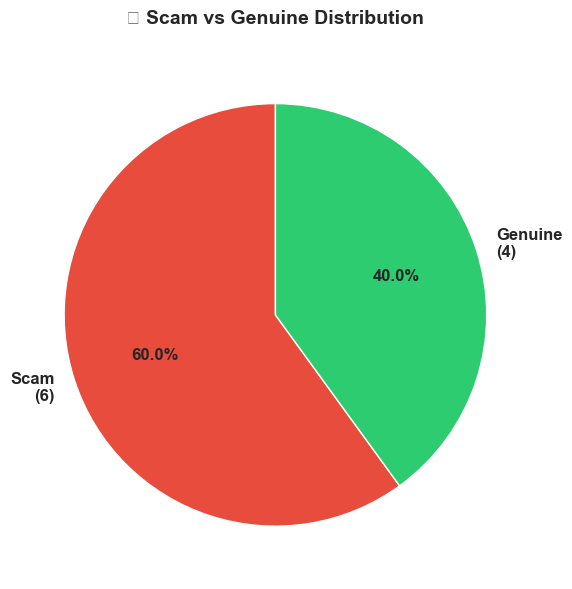

✓ Pie chart saved!


In [16]:
summary = stats.get_stats_summary()

fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#e74c3c', '#2ecc71']
labels = [f"Scam\n({summary['scam']})", f"Genuine\n({summary['genuine']})"]
sizes = [summary['scam'], summary['genuine']]

wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors, 
                                    autopct='%1.1f%%', startangle=90,
                                    textprops={'fontsize': 12, 'weight': 'bold'})

ax.set_title('🔍 Scam vs Genuine Distribution', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../outputs/stats_pie_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Pie chart saved!")

BAR CHARTS

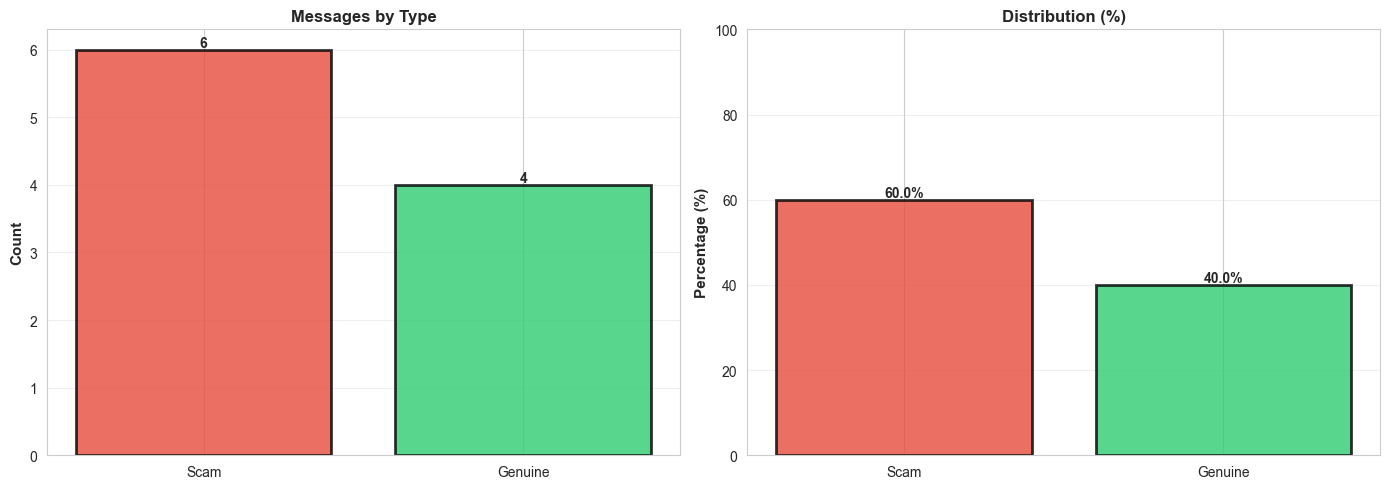

✓ Bar chart saved!


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Count
ax1 = axes[0]
categories = ['Scam', 'Genuine']
counts = [summary['scam'], summary['genuine']]
colors_bar = ['#e74c3c', '#2ecc71']

bars = ax1.bar(categories, counts, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=2)
ax1.set_ylabel('Count', fontsize=11, fontweight='bold')
ax1.set_title('Messages by Type', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# Chart 2: Percentage
ax2 = axes[1]
percentages = [summary['scam_percentage'], summary['genuine_percentage']]
bars2 = ax2.bar(categories, percentages, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=2)
ax2.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
ax2.set_title('Distribution (%)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.grid(axis='y', alpha=0.3)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/stats_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Bar chart saved!")

EXPORT TO CSV


In [18]:
def export_stats_to_csv():
    """Export to CSV"""
    
    predictions = stats.stats['predictions']
    df = pd.DataFrame(predictions)
    
    if len(df) > 0:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df['date'] = df['timestamp'].dt.date
        df['time'] = df['timestamp'].dt.time
        
        df = df[['date', 'time', 'sms', 'prediction', 'confidence', 'risk_level']]
        
        filename = f"../outputs/stats_export_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
        df.to_csv(filename, index=False)
        
        print(f"✓ Exported to: {filename}")
        print(f"\nSample:")
        print(df.head())
    else:
        print("⚠️ No predictions to export")

export_stats_to_csv()

✓ Exported to: ../outputs/stats_export_20260927_085756.csv

Sample:
         date             time                                  sms  \
0  2026-09-27  08:46:54.464925  Mubarak ho! Aap lottery winner hain   
1  2026-09-27  08:46:54.473902                        Kya haal hai?   
2  2026-09-27  08:46:54.477890      URGENT: Verify bank account OTP   
3  2026-09-27  08:46:54.485870        Doodh le aana ghar aatay huay   
4  2026-09-27  08:46:54.489859            Free iPhone limited time!   

  prediction  confidence risk_level  
0       Scam          85       HIGH  
1    Genuine          95        LOW  
2       Scam          92   CRITICAL  
3    Genuine          98        LOW  
4       Scam          88       HIGH  


SUMMARY TABLE

In [19]:
summary = stats.get_stats_summary()

stats_table = pd.DataFrame({
    'Metric': [
        'Total Messages',
        'Scam Messages',
        'Genuine Messages',
        'Scam %',
        'Genuine %'
    ],
    'Value': [
        summary['total'],
        summary['scam'],
        summary['genuine'],
        f"{summary['scam_percentage']:.1f}%",
        f"{summary['genuine_percentage']:.1f}%"
    ]
})

print("\n" + "="*50)
print(" STATISTICS SUMMARY TABLE")
print("="*50)
print(stats_table.to_string(index=False))
print("="*50)


 STATISTICS SUMMARY TABLE
          Metric Value
  Total Messages    10
   Scam Messages     6
Genuine Messages     4
          Scam % 60.0%
       Genuine % 40.0%
